# Phase 3 — Baseline Model Comparison


In [1]:
%run ../src/models/train_baseline_models.py

fold 0 | LogisticRegression AUC=0.6774  F1=0.2208  KS=0.2667
fold 0 | RandomForest       AUC=0.6657  F1=0.0087  KS=0.2424
fold 0 | XGBoost            AUC=0.6771  F1=0.0318  KS=0.2621
fold 0 | LightGBM           AUC=0.6948  F1=0.0115  KS=0.2869
fold 1 | LogisticRegression AUC=0.6749  F1=0.2204  KS=0.2660
fold 1 | RandomForest       AUC=0.6674  F1=0.0091  KS=0.2423
fold 1 | XGBoost            AUC=0.6805  F1=0.0353  KS=0.2653
fold 1 | LightGBM           AUC=0.6949  F1=0.0103  KS=0.2895
fold 2 | LogisticRegression AUC=0.6826  F1=0.2223  KS=0.2727
fold 2 | RandomForest       AUC=0.6674  F1=0.0067  KS=0.2512
fold 2 | XGBoost            AUC=0.6786  F1=0.0396  KS=0.2659
fold 2 | LightGBM           AUC=0.6962  F1=0.0143  KS=0.2936
fold 3 | LogisticRegression AUC=0.6784  F1=0.2186  KS=0.2625
fold 3 | RandomForest       AUC=0.6649  F1=0.0079  KS=0.2423
fold 3 | XGBoost            AUC=0.6797  F1=0.0402  KS=0.2664
fold 3 | LightGBM           AUC=0.6920  F1=0.0095  KS=0.2823
fold 4 | LogisticRegress

In [2]:
summary

,auc_mean,auc_std,f1_mean,f1_std,ks_mean,ks_std
model,,,,,,
LogisticRegression,0.678011,0.002854,0.220163,0.001514,0.265699,0.004644
RandomForest,0.665692,0.001789,0.008296,0.001000,0.245124,0.004031
XGBoost,0.679100,0.001306,0.036180,0.003637,0.265208,0.001759
LightGBM,0.694290,0.001608,0.011517,0.001828,0.288570,0.004232


In [3]:
per_fold

,model,fold,auc,f1,ks
0,LogisticRegression,0,0.677445,0.220757,0.266696
1,RandomForest,0,0.665685,0.008701,0.242412
2,XGBoost,0,0.677095,0.031837,0.262147
3,LightGBM,0,0.694845,0.011542,0.286856
4,LogisticRegression,1,0.674908,0.220427,0.266043
5,RandomForest,1,0.667351,0.009096,0.242344
6,XGBoost,1,0.680530,0.035328,0.265334
7,LightGBM,1,0.694878,0.010322,0.289550
8,LogisticRegression,2,0.682572,0.222255,0.272683
9,RandomForest,2,0.667376,0.006738,0.251237


# Calibration — all 4 models

In [8]:
 %run ../src/models/calibration.py

LogisticRegression | fold 0: calibrated 61,503 held-out rows
LogisticRegression | fold 1: calibrated 61,502 held-out rows
LogisticRegression | fold 2: calibrated 61,502 held-out rows
LogisticRegression | fold 3: calibrated 61,502 held-out rows
LogisticRegression | fold 4: calibrated 61,502 held-out rows
LogisticRegression: Brier raw=0.2236  calibrated=0.0715
RandomForest | fold 0: calibrated 61,503 held-out rows
RandomForest | fold 1: calibrated 61,502 held-out rows
RandomForest | fold 2: calibrated 61,502 held-out rows
RandomForest | fold 3: calibrated 61,502 held-out rows
RandomForest | fold 4: calibrated 61,502 held-out rows
RandomForest: Brier raw=0.0747  calibrated=0.0720
XGBoost | fold 0: calibrated 61,503 held-out rows
XGBoost | fold 1: calibrated 61,502 held-out rows
XGBoost | fold 2: calibrated 61,502 held-out rows
XGBoost | fold 3: calibrated 61,502 held-out rows
XGBoost | fold 4: calibrated 61,502 held-out rows
XGBoost: Brier raw=0.0727  calibrated=0.0717
LightGBM | fold 0: 

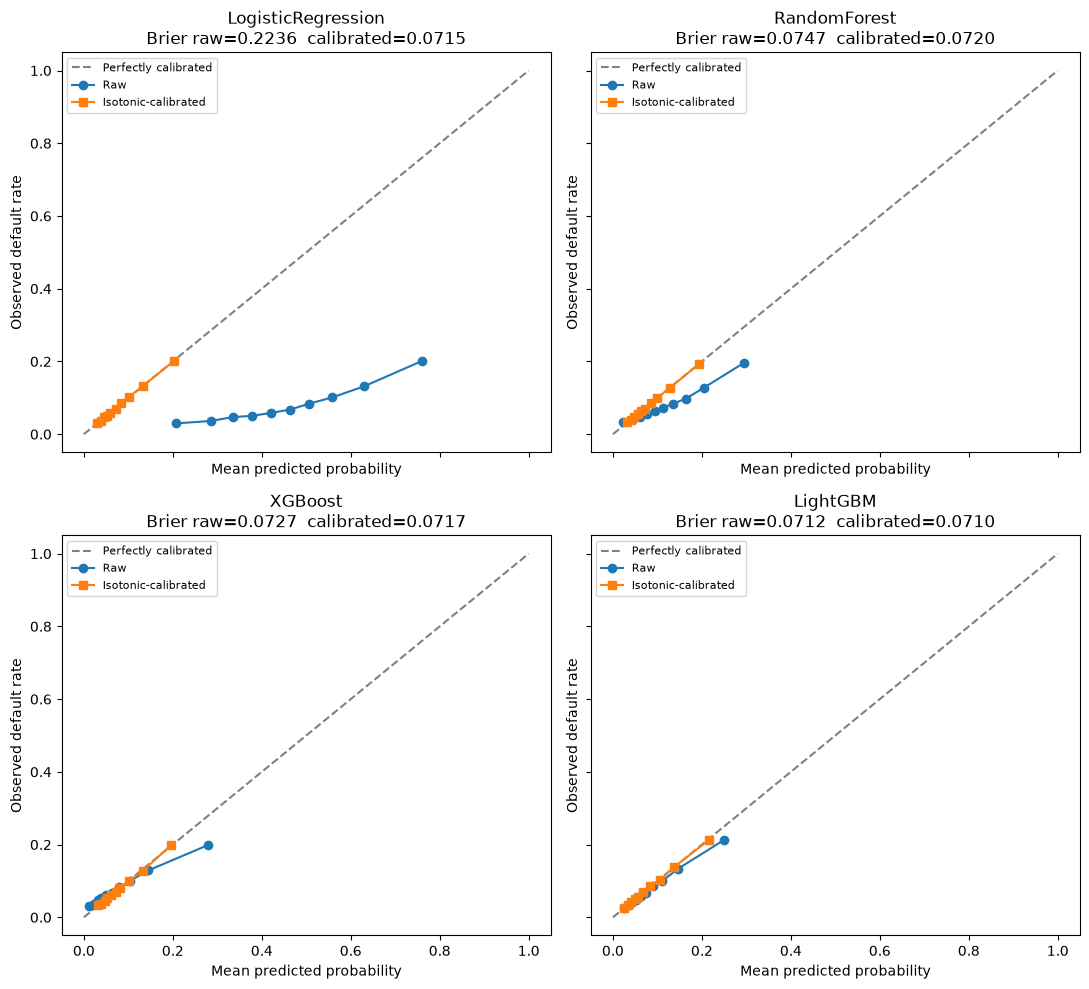

,brier_raw,brier_calibrated
model,,
LogisticRegression,0.2236,0.0715
RandomForest,0.0747,0.0720
XGBoost,0.0727,0.0717
LightGBM,0.0712,0.0710


In [9]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)

for ax, model_name in zip(axes.flat, oof["model"].unique()):
    sub = oof[oof["model"] == model_name]
    frac_pos_raw, mean_pred_raw = calibration_curve(sub["y_true"], sub["proba_raw"], n_bins=10, strategy="quantile")
    frac_pos_cal, mean_pred_cal = calibration_curve(sub["y_true"], sub["proba_calibrated"], n_bins=10, strategy="quantile")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
    ax.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw")
    ax.plot(mean_pred_cal, frac_pos_cal, marker="s", label="Isotonic-calibrated")
    brier_row = quality.loc[model_name]
    ax.set_title(f"{model_name}\nBrier raw={brier_row['brier_raw']:.4f}  calibrated={brier_row['brier_calibrated']:.4f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed default rate")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

quality.round(4)

# Expected Loss + Cost-Sensitive Threshold — all 4 models



In [10]:
%run ../src/models/expected_loss.py

Expected Loss per applicant per model saved: D:\finance\credit-risk-fyp\data\processed\phase3_expected_loss.csv (1,230,044 rows)

=== LogisticRegression (total portfolio EL = 7,839,543,426) ===
threshold=0.00: approval_rate=0.0007  profit=24,988,606
threshold=1.00: approval_rate=1.0000  profit=17,938,266,265
Optimal threshold = 0.220  profit=18,067,579,896  approval_rate=0.9733  approved_default_rate=0.0755

=== RandomForest (total portfolio EL = 7,983,438,686) ===
threshold=0.00: approval_rate=0.0000  profit=0
threshold=1.00: approval_rate=1.0000  profit=17,938,266,265
Optimal threshold = 0.240  profit=17,990,727,543  approval_rate=0.9831  approved_default_rate=0.0775

=== XGBoost (total portfolio EL = 7,905,365,280) ===
threshold=0.00: approval_rate=0.0007  profit=24,609,052
threshold=1.00: approval_rate=1.0000  profit=17,938,266,265
Optimal threshold = 0.230  profit=18,038,761,962  approval_rate=0.9798  approved_default_rate=0.0767

=== LightGBM (total portfolio EL = 7,812,085,933) 

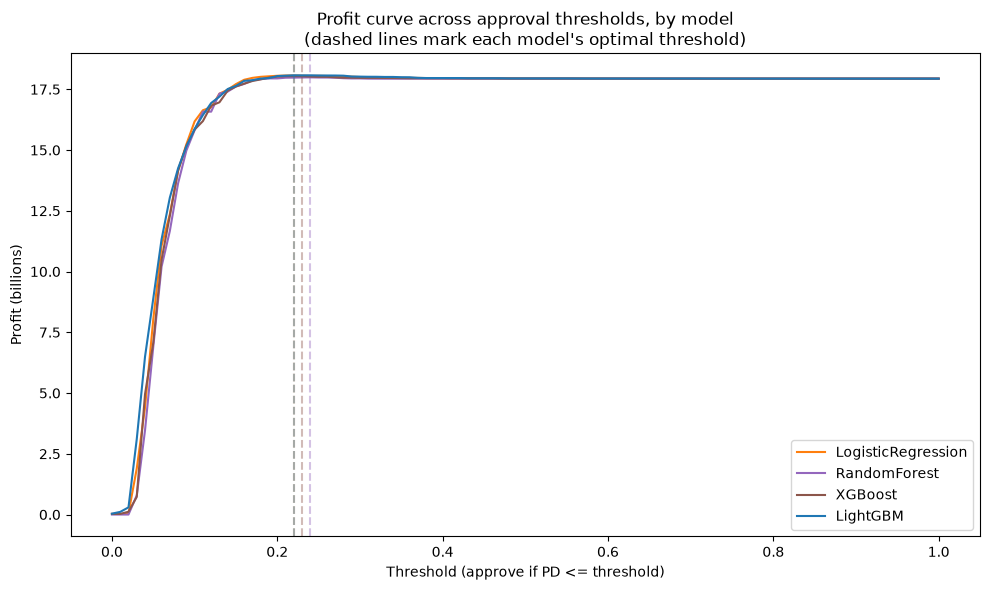

,threshold,profit,approval_rate,approved_default_rate
model,,,,
LogisticRegression,0.22,1.806758e+10,0.9733,0.0755
RandomForest,0.24,1.799073e+10,0.9831,0.0775
XGBoost,0.23,1.803876e+10,0.9798,0.0767
LightGBM,0.22,1.807537e+10,0.9697,0.0747


In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))
colors = {"LogisticRegression": "tab:orange", "RandomForest": "tab:purple", "XGBoost": "tab:brown", "LightGBM": "tab:blue"}

for model_name in optima_df.index:
    curve = all_curves[all_curves["model"] == model_name]
    ax1.plot(curve["threshold"], curve["profit"] / 1e9, label=model_name, color=colors.get(model_name))
    best_t = optima_df.loc[model_name, "threshold"]
    ax1.axvline(best_t, color=colors.get(model_name), linestyle="--", alpha=0.4)

ax1.set_xlabel("Threshold (approve if PD <= threshold)")
ax1.set_ylabel("Profit (billions)")
ax1.set_title("Profit curve across approval thresholds, by model\n(dashed lines mark each model's optimal threshold)")
ax1.legend()
plt.tight_layout()
plt.show()

optima_df.round(4)

# Final Phase 3 comparison table

In [12]:
final_table = (
    summary[["auc_mean", "f1_mean", "ks_mean"]]
    .join(quality)
    .join(optima_df[["threshold", "profit", "approval_rate", "approved_default_rate"]].rename(columns={
        "threshold": "optimal_threshold",
        "profit": "profit_at_optimum",
    }))
)
final_table.to_csv("../data/processed/phase3_final_comparison_table.csv")
final_table.round(4)

,auc_mean,f1_mean,ks_mean,brier_raw,brier_calibrated,optimal_threshold,profit_at_optimum,approval_rate,approved_default_rate
model,,,,,,,,,
LogisticRegression,0.6780,0.2202,0.2657,0.2236,0.0715,0.22,1.806758e+10,0.9733,0.0755
RandomForest,0.6657,0.0083,0.2451,0.0747,0.0720,0.24,1.799073e+10,0.9831,0.0775
XGBoost,0.6791,0.0362,0.2652,0.0727,0.0717,0.23,1.803876e+10,0.9798,0.0767
LightGBM,0.6943,0.0115,0.2886,0.0712,0.0710,0.22,1.807537e+10,0.9697,0.0747
